In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

Preprocessing Data

In [ ]:

# Define dataset paths for fake and real images
fakedata_path = "/content/drive/MyDrive/dataset/training_fake"
realdata_path = "/content/drive/MyDrive/dataset/training_real"

# Parameters
batch_size = 16
img_size = (128, 128)  # Resize all images to the same size

# Load the training set (80%) from both fake and real data directories
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/dataset/',  # Parent directory containing both 'training_fake' and 'training_real'
    validation_split=0.2,  # 20% of the dataset for validation
    subset="training",     # Specify subset as training
    seed=123,              # Seed for reproducibility
    image_size=img_size,   # Resize images to the target size
    batch_size=batch_size,
    label_mode='int',      # Labels as integers for classification (1 for real, 0 for fake)
    shuffle=True           # Shuffle the data for better training
)
print("Class names:", train_dataset.class_names)
# Load the validation set (20%) from both fake and real data directories
val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/dataset/',  # Parent directory containing both 'training_fake' and 'training_real'
    validation_split=0.2,  # 20% of the dataset for validation
    subset="validation",   # Specify subset as validation
    seed=123,
    image_size=img_size,   # Resize images to the target size
    batch_size=batch_size,
    label_mode='int',      # Labels as integers for classification (1 for real, 0 for fake)
    shuffle=True           # Shuffle the data for better validation
)




data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply augmentation during preprocessing
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

Found 2041 files belonging to 2 classes.
Using 1633 files for training.
Class names: ['training_Zfake', 'training_real']
Found 2041 files belonging to 2 classes.
Using 408 files for validation.


FOR OPTIMIZATION


In [ ]:
# Normalize data
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Cache, shuffle, and prefetch for better performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


Training Phase (USED FOR BEST Accuracy)

In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.4900 - loss: 1.0537 - val_accuracy: 0.5221 - val_loss: 0.7536
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5808 - loss: 0.7991 - val_accuracy: 0.4975 - val_loss: 0.7932
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5790 - loss: 0.7801 - val_accuracy: 0.5245 - val_loss: 0.9366
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6171 - loss: 0.7037 - val_accuracy: 0.5466 - val_loss: 0.7381
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6205 - loss: 0.6789 - val_accuracy: 0.5588 - val_loss: 0.7217
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.6688 - loss: 0.6205 - val_accuracy: 0.5784 - val_loss: 0.7457
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6946 - loss: 0.5856 - val_accuracy: 0.5392 - val_loss: 0.7458
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7018 - loss: 0.5682 - val_accu

TRAINING PHASE (Depreciated Due To Poor Accuracy)


In [ ]:
# Compile the model

model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),  # Rescale pixel values
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # For binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 73s 694ms/step - accuracy: 0.5331 - loss: 0.7475 - val_accuracy: 0.5196 - val_loss: 0.6861
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 72s 597ms/step - accuracy: 0.5799 - loss: 0.6769 - val_accuracy: 0.5564 - val_loss: 0.6805
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 591ms/step - accuracy: 0.6231 - loss: 0.6434 - val_accuracy: 0.6054 - val_loss: 0.6804
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 82s 600ms/step - accuracy: 0.6697 - loss: 0.6038 - val_accuracy: 0.5466 - val_loss: 0.9028
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 600ms/step - accuracy: 0.7286 - loss: 0.5223 - val_accuracy: 0.5784 - val_loss: 0.8233
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 598ms/step - accuracy: 0.8022 - loss: 0.4196 - val_accuracy: 0.5735 - val_loss: 0.8421
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 82s 589ms/step - accuracy: 0.8840 - loss: 0.2874 - val_accuracy: 0.5735 - val_loss: 0.9456
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 83s 606ms/step - accuracy: 0.9139 - loss: 0

Save The Model


In [ ]:
model.save("cnn_model3.keras")

Display The Image

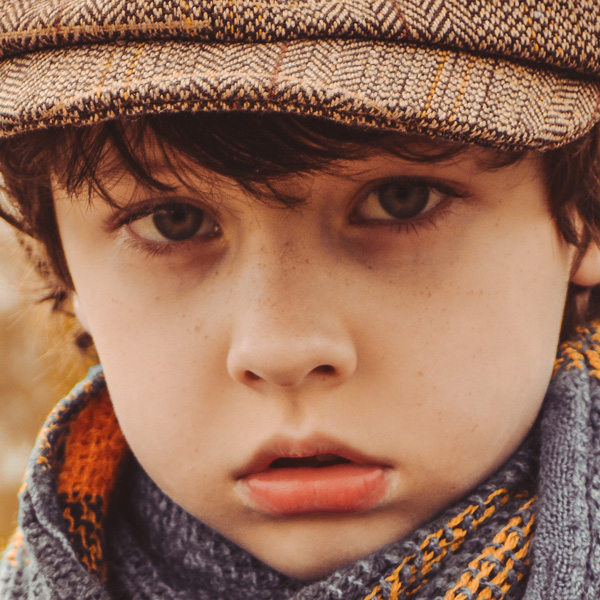

In [ ]:
from IPython.display import Image

# Provide the file path of the image
Image(filename='/content/real_00034.jpg')

TESTING PHASE


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("/content/bestmodel.keras")

# Load and preprocess an image
img_path = "/content/fake_0.jpg"  # Replace with your image path
img = image.load_img(img_path, target_size=(128, 128))  # Resize to model input size
img_array = image.img_to_array(img)  # Convert to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize if trained with normalization

# Predict
prediction = model.predict(img_array)[0][0]

# Interpret the result
if prediction > 0.5:
    print("The image is Real.")
else:
    print("The image is Fake.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
The image is Real.


Extra Graph

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

NameError: name 'plt' is not defined